In [40]:
import json
import pathlib
import pandas as pd

# Override to a specific path to inspect a particular run; leave None to auto-pick latest.
# EVENTS_FILE = '../data/25-05-2026-17:02.jsonl'
EVENTS_FILE = None

if EVENTS_FILE is None:
    sim_data = pathlib.Path('..') / 'data'
    candidates = list(sim_data.glob('*.jsonl'))
    if not candidates:
        raise FileNotFoundError(f'no *.jsonl under {sim_data}')
    EVENTS_FILE = max(candidates, key=lambda p: p.stat().st_mtime)
else:
    EVENTS_FILE = pathlib.Path(EVENTS_FILE)

print(f'loading {EVENTS_FILE}')

records = [json.loads(line) for line in EVENTS_FILE.read_text().splitlines() if line.strip()]
df = pd.json_normalize(records).sort_values('ts').reset_index(drop=True)
print(f"{len(df)} events, {df['node'].nunique()} nodes, span {df['ts'].max() - df['ts'].min():.0f}s")
df.head()

loading ../data/02-06-2026-11:23.jsonl
8591 events, 52 nodes, span 1680s


,ts,src_ip,timestamp,node,event,data.parent,data.btc_address,data.starting_balance_sat,data.version,data.ts,...,data.reason,data.machine_id,data.token_prefix,data.debited_cents,data.token_balance_cents_after,data.new_expiration_wall_ts,data.expiration_wall_ts,data.reaped_at_wall_ts,data.lxc_stop_ok,data.lxc_delete_ok
0,1.780389e+09,10.215.172.81,2026-06-02T08:25:53.286880+00:00,genesis,birth,genesis,bcrt1qufthsz89r0stdrtw8arzt8qq6ckes25vaplkhl,19411859.0,unknown,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.780389e+09,10.215.172.81,2026-06-02T08:25:53.291024+00:00,genesis,state_snapshot,NaN,bcrt1qufthsz89r0stdrtw8arzt8qq6ckes25vaplkhl,NaN,NaN,1.780389e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.780389e+09,10.215.172.81,2026-06-02T08:26:03.294880+00:00,genesis,state_snapshot,NaN,bcrt1qufthsz89r0stdrtw8arzt8qq6ckes25vaplkhl,NaN,NaN,1.780389e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.780389e+09,10.215.172.81,2026-06-02T08:26:13.299568+00:00,genesis,state_snapshot,NaN,bcrt1qufthsz89r0stdrtw8arzt8qq6ckes25vaplkhl,NaN,NaN,1.780389e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.780389e+09,10.215.172.81,2026-06-02T08:26:23.302818+00:00,genesis,state_snapshot,NaN,bcrt1qufthsz89r0stdrtw8arzt8qq6ckes25vaplkhl,NaN,NaN,1.780389e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


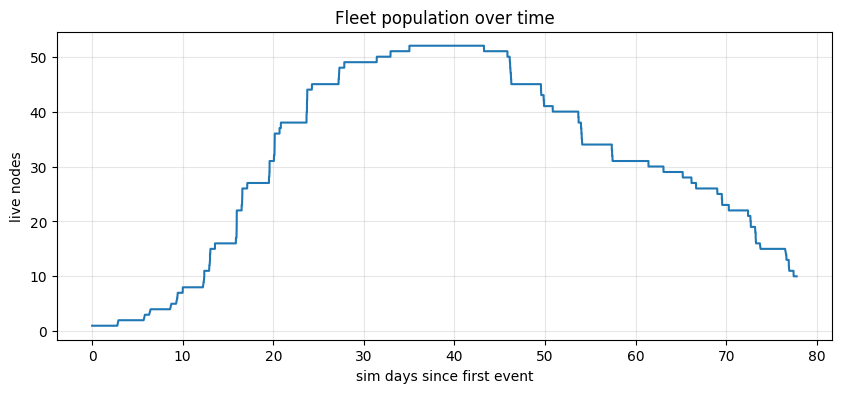

In [41]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import tomllib
except ImportError:
    import tomli as tomllib

with open(pathlib.Path('..') / 'sim_config.toml', 'rb') as f:
    _cfg = tomllib.load(f)
TIME_SCALE = _cfg['sporestack']['time_scale']

snaps = df[df['event'] == 'state_snapshot'].copy()
ts_axis = sorted(df['ts'].unique())
t0 = df['ts'].min()

# --- Liveness via pure event replay (trust the backend's death logic) -------
# server_expired is the backend's single source of truth for death: both the
# funding-expiry reaper (mock_sporestack) and the funding-gated heartbeat
# eviction (event_collector) converge on it. So we reconstruct the live
# population by replaying births vs. deaths instead of inferring death from
# snapshot silence (the old DEATH_TIMEOUT sliding window, which counted
# silent-but-funded nodes as dead even while the backend kept funding them).
_first_seen = df.groupby('node')['ts'].min()                  # first appearance of any node
_birth_ts   = df[df['event'] == 'birth'].groupby('node')['ts'].min()
born_ts     = _birth_ts.combine_first(_first_seen)            # prefer birth event, else first-seen
death_ts    = (df[df['event'] == 'server_expired']
                 .dropna(subset=['data.friendly_name'])
                 .groupby('data.friendly_name')['ts'].min()
                 .reindex(born_ts.index))                     # ignore deaths with no matching node

_node_arr  = born_ts.index.to_numpy()
_born_arr  = born_ts.to_numpy()
_death_arr = death_ts.to_numpy()                              # NaN where still alive
_born_sorted = np.sort(_born_arr)
_died_sorted = np.sort(_death_arr[~np.isnan(_death_arr)])


def live_count_at(axis):
    """Live node count at each t in axis: born by t minus expired by t."""
    return [
        int(np.searchsorted(_born_sorted, t, side='right')
            - np.searchsorted(_died_sorted, t, side='right'))
        for t in axis
    ]


def live_nodes_at(t):
    """Set of node names alive at time t (born and not yet expired)."""
    alive = (_born_arr <= t) & (np.isnan(_death_arr) | (_death_arr > t))
    return set(_node_arr[alive])


populations = live_count_at(ts_axis)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot([(t - t0) * TIME_SCALE / 86400 for t in ts_axis], populations)
ax.set_xlabel('sim days since first event')
ax.set_ylabel('live nodes')
ax.set_title('Fleet population over time')
ax.grid(True, alpha=0.3)
plt.show()

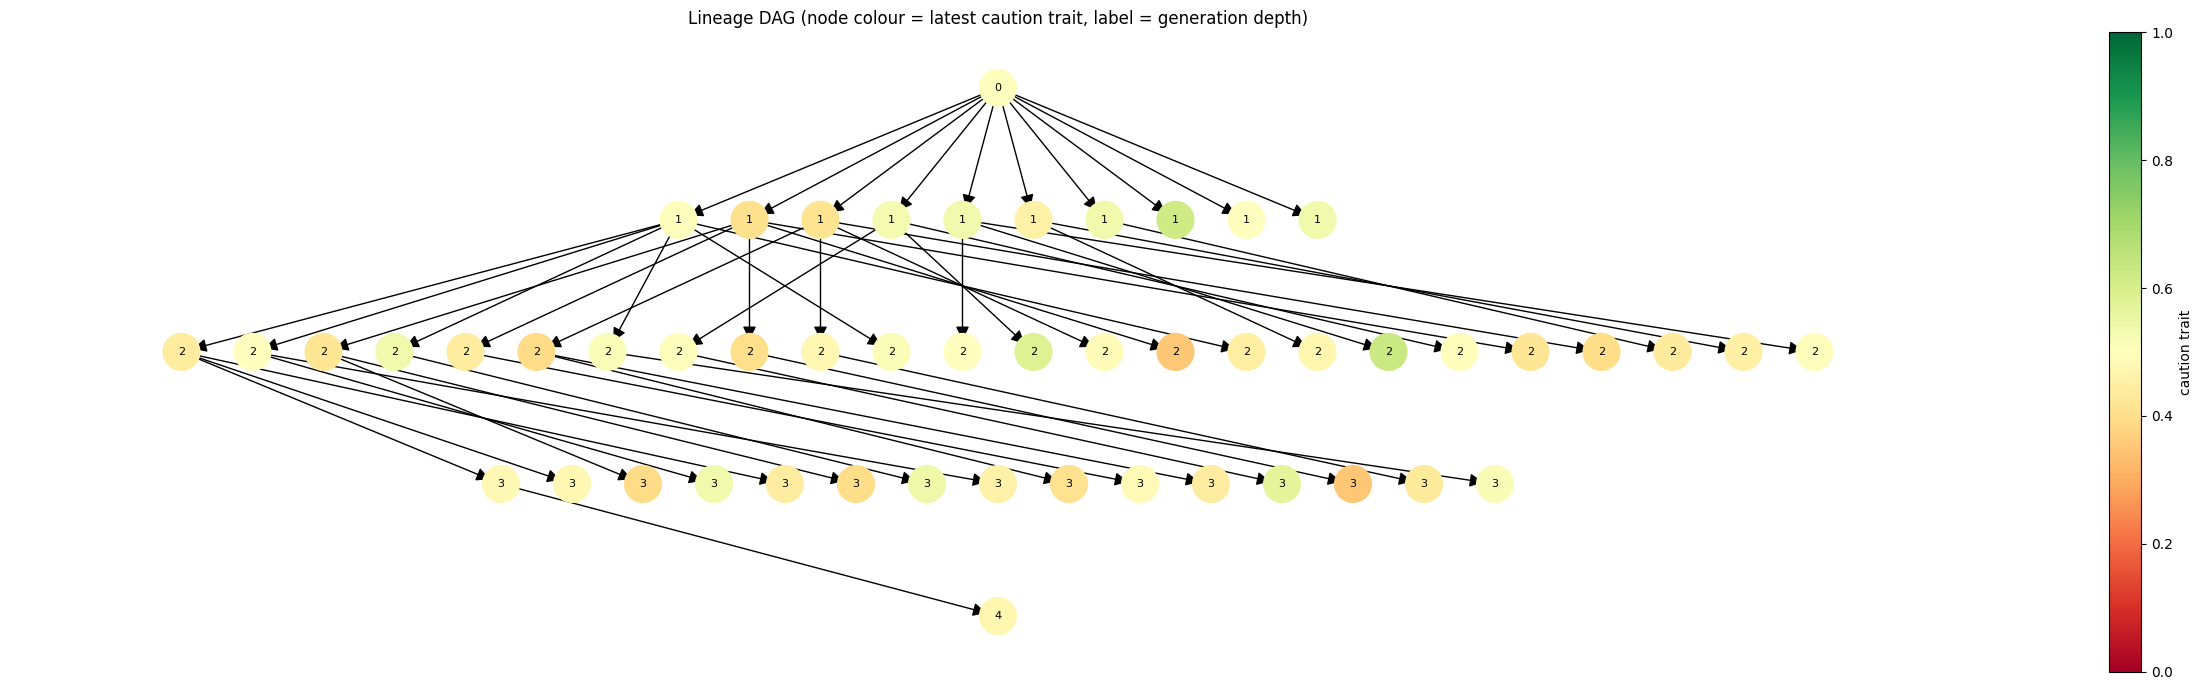

In [30]:
import networkx as nx
from collections import defaultdict

births = df[df['event'] == 'birth']
caution_by_node = (
    snaps.sort_values('ts')
         .groupby('node')['data.caution_trait']
         .last()
         .to_dict()
)

G = nx.DiGraph()
for _, row in births.iterrows():
    parent, child = row.get('data.parent'), row['node']
    G.add_node(child)
    if parent and parent != child:
        G.add_edge(parent, child)

depth_labels = {}
for node in G.nodes:
    try:
        depth_labels[node] = nx.shortest_path_length(G, 'genesis', node)
    except (nx.NodeNotFound, nx.NetworkXNoPath):
        depth_labels[node] = '?'

# Hierarchical tree layout: group by depth, spread horizontally
levels = defaultdict(list)
for node, depth in depth_labels.items():
    if isinstance(depth, int):
        levels[depth].append(node)

pos = {}
for depth, nodes in levels.items():
    for i, node in enumerate(nodes):
        pos[node] = (i - (len(nodes) - 1) / 2, -depth)
for node in G.nodes:
    if node not in pos:
        pos[node] = (0, 1)

caution_vals = [caution_by_node.get(n, 0.5) for n in G.nodes]

fig, ax = plt.subplots(figsize=(max(10, len(G) // 2), 7))
nx.draw_networkx_nodes(G, pos, node_color=caution_vals, cmap='RdYlGn', vmin=0, vmax=1, node_size=700, ax=ax)
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=20, ax=ax)
nx.draw_networkx_labels(G, pos, labels=depth_labels, font_size=8, ax=ax)
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, ax=ax, label='caution trait')
ax.set_title('Lineage DAG (node colour = latest caution trait, label = generation depth)')
ax.axis('off')
plt.tight_layout()
plt.show()

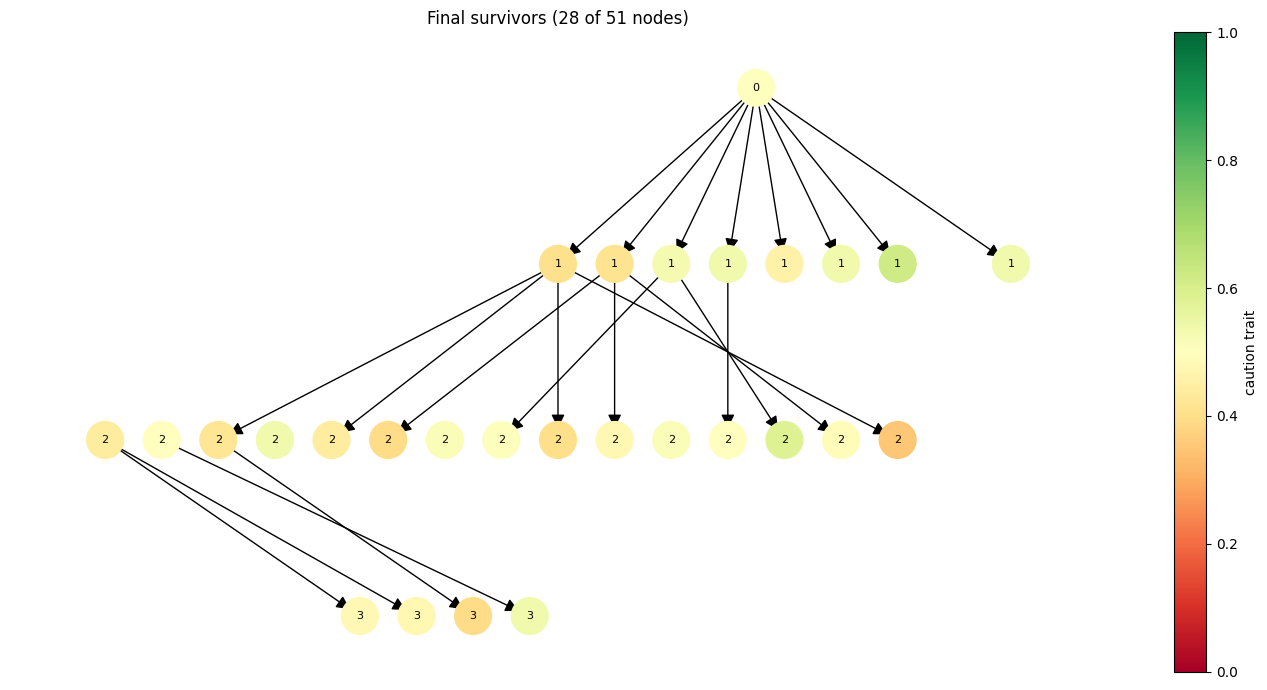

In [31]:
dead_nodes = set(
    df[df['event'] == 'server_expired']['data.friendly_name']
      .dropna().astype(str)
)
dead_nodes.discard('')
survivors = [n for n in G.nodes if n not in dead_nodes]
S = G.subgraph(survivors)

survivor_caution = [caution_by_node.get(n, 0.5) for n in S.nodes]
survivor_labels  = {n: depth_labels.get(n, '?') for n in S.nodes}

fig, ax = plt.subplots(figsize=(max(10, len(S) // 2), 7))
nx.draw_networkx_nodes(S, pos, node_color=survivor_caution, cmap='RdYlGn', vmin=0, vmax=1, node_size=700, ax=ax)
nx.draw_networkx_edges(S, pos, arrows=True, arrowsize=20, ax=ax)
nx.draw_networkx_labels(S, pos, labels=survivor_labels, font_size=8, ax=ax)
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, ax=ax, label='caution trait')
ax.set_title(f'Final survivors ({len(survivors)} of {len(G)} nodes)')
ax.axis('off')
plt.tight_layout()
plt.show()

In [32]:
# import io
# from PIL import Image as PILImage
# from IPython.display import Image
#
# try:
#     import tomllib
# except ImportError:
#     import tomli as tomllib
#
# with open(pathlib.Path('..') / 'sim_config.toml', 'rb') as f:
#     cfg = tomllib.load(f)
# BTC_USD            = cfg['sporestack']['btc_usd']
# MONTHLY_COST_CENTS = cfg['sporestack']['monthly_cost_cents']
# TIME_SCALE         = cfg['sporestack']['time_scale']
# SATS_PER_BTC       = 100_000_000
# CENTS_PER_SAT      = (BTC_USD * 100) / SATS_PER_BTC
# DAYS_PER_MONTH     = 30.0
# PENDING_COLOR      = '#bfbfbf'   # grey for nodes that haven't reported BTC yet
#
# def months_from_balance(balance_sat: float) -> float:
#     return balance_sat * CENTS_PER_SAT / MONTHLY_COST_CENTS
#
# def total_months(balance_sat: float, days_remaining) -> float:
#     """Total runway = convertible BTC + pre-paid SporeStack days."""
#     months = months_from_balance(balance_sat) if balance_sat is not None and balance_sat == balance_sat else 0.0
#     if days_remaining is not None and days_remaining == days_remaining:
#         months += float(days_remaining) / DAYS_PER_MONTH
#     return months
#
# def real_elapsed_str(wall_s: float) -> str:
#     """Wall-clock seconds → sim-real-world equivalent, formatted."""
#     sim_s  = wall_s * TIME_SCALE
#     months = sim_s / (DAYS_PER_MONTH * 86400)
#     days   = sim_s / 86400
#     hours  = sim_s / 3600
#     if months >= 1.0:
#         return f'{months:.2f}mo'
#     if days >= 1.0:
#         return f'{days:.1f}d'
#     return f'{hours:.1f}h'
#
# # Tunables.
# SNAPS_PER_INTERVAL = 5     # max aggregated snapshot frames per birth/death interval
# BIRTH_DEATH_MS     = 500   # GIF frame duration for lifecycle events
# SNAP_MS            = 250   # GIF frame duration for snapshot-aggregate frames
# RED_MONTHS         = 1.0   # months remaining ≤ this → dark red
# GREEN_MONTHS       = 6.0  # months remaining ≥ this → full green
#
# # Chronological lineage animation with runway-colored nodes.
# # Frame kinds:
# #   birth    : add node + directed edge from parent
# #   death    : remove node + its incoming edge (children stay, now orphaned)
# #   snap_agg : batch of (node, balance_sat, days_remaining) updates accumulated
# #              between two consecutive lifecycle anchors, applied in order
# # Runway = BTC-convertible months + pre-paid VPS days_remaining/30.
# # Pre-inheritance gate: snapshots reporting balance_sat ≤ 0 are ignored until
# # the node first reports a positive balance (after that, 0-balance snapshots —
# # e.g. post-failsafe sweep — are respected). Nodes still in the pending state
# # are drawn grey to distinguish from genuinely-funded green nodes.
# # Layout is the global `pos` from the static lineage cell.
#
# births_evt = df[df['event'] == 'birth'][['ts', 'node', 'data.parent']].copy()
# births_evt = births_evt.rename(columns={'data.parent': 'parent'})
# births_evt['kind'] = 'birth'
#
# deaths_evt = df[df['event'] == 'server_expired'][['ts', 'data.friendly_name']].copy()
# deaths_evt = deaths_evt.rename(columns={'data.friendly_name': 'node'})
# deaths_evt = deaths_evt[deaths_evt['node'].fillna('').astype(str).str.len() > 0]
# deaths_evt['parent'] = None
# deaths_evt['kind'] = 'death'
#
# anchors = (
#     pd.concat([births_evt, deaths_evt], ignore_index=True, sort=False)
#       .sort_values('ts', kind='stable')
#       .reset_index(drop=True)
# )
# snaps_sorted = (
#     df[df['event'] == 'state_snapshot'][
#         ['ts', 'node', 'data.btc_balance_sat', 'data.days_remaining']
#     ]
#       .rename(columns={
#           'data.btc_balance_sat': 'balance_sat',
#           'data.days_remaining':  'days_remaining',
#       })
#       .sort_values('ts', kind='stable')
#       .reset_index(drop=True)
# )
#
# def _emit_snap_chunks(timeline, bin_df):
#     n = len(bin_df)
#     if not n:
#         return
#     k = min(SNAPS_PER_INTERVAL, n)
#     sizes = [n // k + (1 if i < n % k else 0) for i in range(k)]
#     start = 0
#     for sz in sizes:
#         chunk = bin_df.iloc[start:start + sz]
#         start += sz
#         if not len(chunk):
#             continue
#         timeline.append({
#             'kind': 'snap_agg',
#             'ts': float(chunk['ts'].iloc[-1]),
#             'duration_ms': SNAP_MS,
#             'updates': list(zip(chunk['node'].tolist(),
#                                 chunk['balance_sat'].tolist(),
#                                 chunk['days_remaining'].tolist())),
#         })
#
# timeline = []
# prev_ts = -float('inf')
# for _, anc in anchors.iterrows():
#     bin_df = snaps_sorted[(snaps_sorted['ts'] > prev_ts) &
#                           (snaps_sorted['ts'] < anc['ts'])]
#     _emit_snap_chunks(timeline, bin_df)
#     timeline.append({
#         'kind': anc['kind'],
#         'ts': float(anc['ts']),
#         'duration_ms': BIRTH_DEATH_MS,
#         'node': anc['node'],
#         'parent': anc.get('parent'),
#     })
#     prev_ts = anc['ts']
# _emit_snap_chunks(timeline, snaps_sorted[snaps_sorted['ts'] > prev_ts])
#
# t0_anim = timeline[0]['ts'] if timeline else df['ts'].min()
# n_birth = sum(1 for e in timeline if e['kind'] == 'birth')
# n_death = sum(1 for e in timeline if e['kind'] == 'death')
# n_snap  = sum(1 for e in timeline if e['kind'] == 'snap_agg')
# print(f'{len(timeline)} frames ({n_birth} births, {n_death} deaths, '
#       f'{n_snap} snapshot-aggregates from {len(snaps_sorted)} snapshots) '
#       f'@ time_scale={TIME_SCALE}×')
#
# alive_nodes = set()
# alive_edges = set()
# current_months = {}
# btc_received = set()   # nodes that have reported positive balance at least once
#
# def _runway_t(node):
#     cur = current_months.get(node)
#     if cur is None:
#         return None  # caller treats this as "pending → grey"
#     span = GREEN_MONTHS - RED_MONTHS
#     return max(0.0, min(1.0, (cur - RED_MONTHS) / span))
#
# def _is_missing(x):
#     return x is None or (isinstance(x, float) and x != x)
#
# fig_a, ax_a = plt.subplots(figsize=(max(10, len(G) // 2), 7))
# fig_a.colorbar(
#     plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(RED_MONTHS, GREEN_MONTHS)),
#     ax=ax_a, label=f'total runway months (BTC + pre-paid VPS; red ≤ {RED_MONTHS:.0f}, green ≥ {GREEN_MONTHS:.0f}; grey = pending)',
# )
#
# def _draw_frame(i, ev):
#     ax_a.clear()
#     if ev['kind'] == 'birth':
#         alive_nodes.add(ev['node'])
#         if ev['parent'] and ev['parent'] != ev['node']:
#             alive_edges.add((ev['parent'], ev['node']))
#     elif ev['kind'] == 'death':
#         alive_nodes.discard(ev['node'])
#         for e in {e for e in alive_edges if e[1] == ev['node']}:
#             alive_edges.discard(e)
#     else:
#         for node, balance, days in ev['updates']:
#             if node not in btc_received:
#                 if _is_missing(balance) or balance <= 0:
#                     continue  # pre-inheritance — ignore, node stays in pending/grey
#                 btc_received.add(node)
#             current_months[node] = total_months(balance, days)
#
#     nodes_alive   = [n for n in alive_nodes if n in pos]
#     edges_to_draw = [e for e in alive_edges if e[0] in pos and e[1] in pos]
#     nodes_funded, funded_colors = [], []
#     nodes_pending = []
#     for n in nodes_alive:
#         t = _runway_t(n)
#         if t is None:
#             nodes_pending.append(n)
#         else:
#             nodes_funded.append(n)
#             funded_colors.append(t)
#     labels = {n: depth_labels.get(n, '?') for n in nodes_alive}
#
#     if nodes_funded:
#         nx.draw_networkx_nodes(
#             G.subgraph(nodes_funded), pos,
#             nodelist=nodes_funded, node_color=funded_colors,
#             cmap='RdYlGn', vmin=0, vmax=1, node_size=700, ax=ax_a,
#         )
#     if nodes_pending:
#         nx.draw_networkx_nodes(
#             G.subgraph(nodes_pending), pos,
#             nodelist=nodes_pending, node_color=PENDING_COLOR,
#             node_size=700, ax=ax_a,
#         )
#     if nodes_alive:
#         nx.draw_networkx_labels(
#             G.subgraph(nodes_alive), pos, labels=labels, font_size=8, ax=ax_a,
#         )
#     if edges_to_draw:
#         nx.draw_networkx_edges(
#             G, pos, edgelist=edges_to_draw,
#             arrows=True, arrowsize=20, ax=ax_a,
#         )
#
#     xs = [pos[n][0] for n in pos]
#     ys = [pos[n][1] for n in pos]
#     if xs and ys:
#         ax_a.set_xlim(min(xs) - 1, max(xs) + 1)
#         ax_a.set_ylim(min(ys) - 1, max(ys) + 1)
#
#     elapsed = ev['ts'] - t0_anim
#     if ev['kind'] == 'birth':
#         title_tail = f"BIRTH: {ev['parent']} → {ev['node']}"
#     elif ev['kind'] == 'death':
#         title_tail = f"DEATH: {ev['node']}"
#     else:
#         title_tail = f"SNAP×{len(ev['updates'])}"
#     real_t = real_elapsed_str(elapsed)
#     ax_a.set_title(
#         f'Time Elapsed: {real_t} '
#         f'[{i+1}/{len(timeline)}]  {title_tail}'
#     )
#     ax_a.axis('off')
#
# pil_frames, durations = [], []
# for i, ev in enumerate(timeline):
#     _draw_frame(i, ev)
#     fig_a.canvas.draw()
#     buf = io.BytesIO()
#     fig_a.savefig(buf, format='png')
#     buf.seek(0)
#     pil_frames.append(PILImage.open(buf).convert('P', palette=PILImage.ADAPTIVE))
#     durations.append(ev['duration_ms'])
# plt.close(fig_a)
#
# gif_path = pathlib.Path('lineage_' + EVENTS_FILE.stem + '.gif')
# pil_frames[0].save(
#     gif_path, save_all=True, append_images=pil_frames[1:],
#     duration=durations, loop=0, optimize=True,
# )
# print(f'saved {gif_path}')
# Image(filename=str(gif_path))

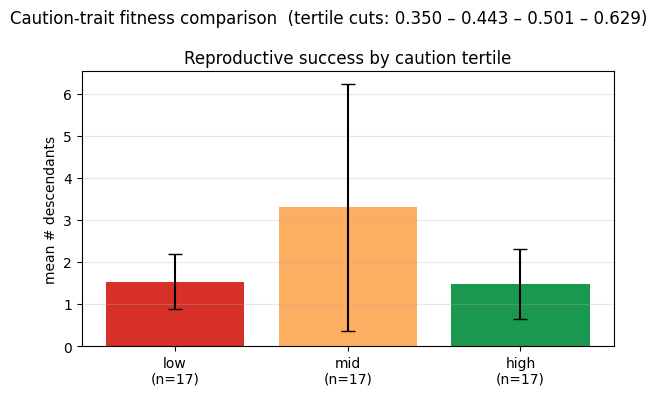

per-tertile summary:
   low: n=17, mean descendants=1.53 (SEM 0.65)
   mid: n=17, mean descendants=3.29 (SEM 2.92)
  high: n=17, mean descendants=1.47 (SEM 0.83)


In [33]:
# 1. Caution-trait fitness comparison
rows = []
for node, caution in caution_by_node.items():
    if pd.isna(caution) or node not in G:
        continue
    rows.append({
        'node': node,
        'caution': caution,
        'n_descendants': len(nx.descendants(G, node)),
    })

caution_df = pd.DataFrame(rows)

if caution_df.empty or caution_df['caution'].nunique() < 3:
    print(f'insufficient caution diversity for tertile split (n={len(caution_df)})')
else:
    caution_df['tertile'], bins = pd.qcut(
        caution_df['caution'], 3, labels=['low', 'mid', 'high'],
        retbins=True, duplicates='drop',
    )

    order = ['low', 'mid', 'high']
    agg = caution_df.groupby('tertile', observed=True).agg(
        n=('node', 'size'),
        mean_descendants=('n_descendants', 'mean'),
        sem_descendants=('n_descendants', 'sem'),
    ).reindex(order)

    colors = ['#d73027', '#fdae61', '#1a9850']
    positions = list(range(len(order)))
    x_labels = [f'{lbl}\n(n={int(agg.loc[lbl, "n"])})' for lbl in order]

    fig, ax2 = plt.subplots(figsize=(6, 4))

    ax2.bar(
        positions, agg['mean_descendants'],
        yerr=agg['sem_descendants'].fillna(0),
        capsize=5, color=colors,
    )
    ax2.set_xticks(positions)
    ax2.set_xticklabels(x_labels)
    ax2.set_ylabel('mean # descendants')
    ax2.set_title('Reproductive success by caution tertile')
    ax2.grid(True, alpha=0.3, axis='y')

    bins_str = ' – '.join(f'{b:.3f}' for b in bins)
    fig.suptitle(f'Caution-trait fitness comparison  (tertile cuts: {bins_str})')
    plt.tight_layout()
    plt.show()

    print('per-tertile summary:')
    for lbl in order:
        row = agg.loc[lbl]
        print(
            f'  {lbl:>4}: n={int(row["n"])}, '
            f'mean descendants={row["mean_descendants"]:.2f} '
            f'(SEM {row["sem_descendants"]:.2f})'
        )


/tmp/ipykernel_168180/2714519546.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fontsize=9)


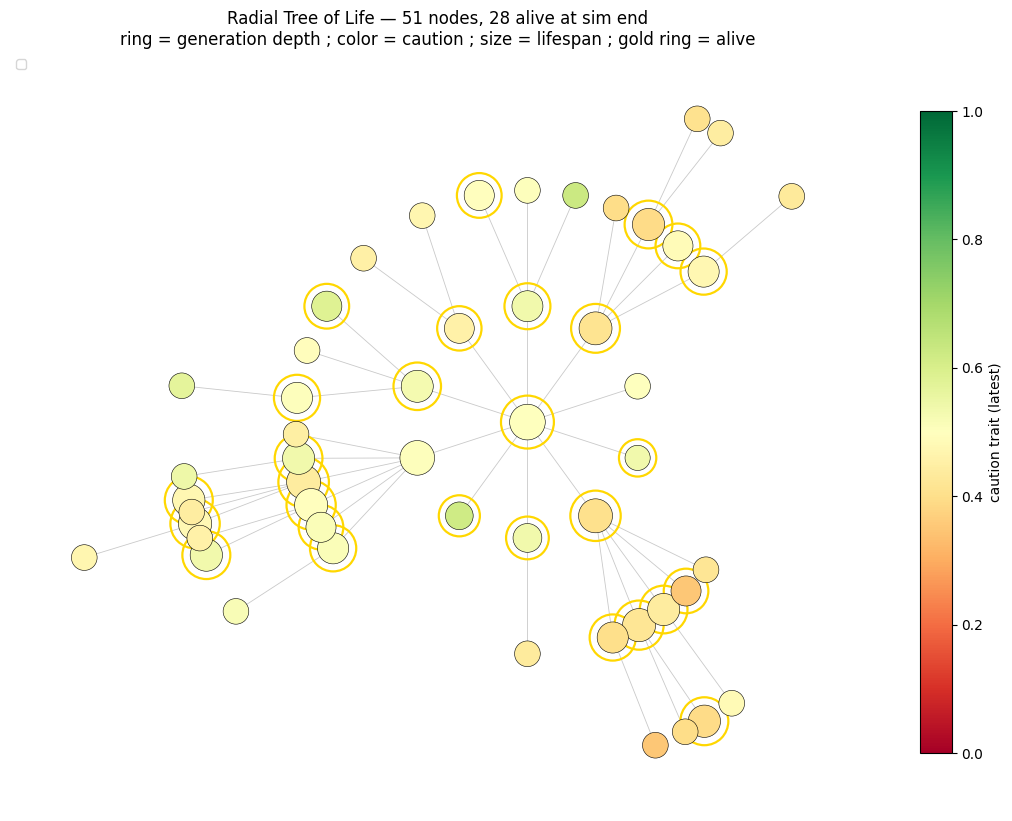

In [34]:
# A2. Radial Tree of Life
# Genesis at center, ring = generation depth, color = caution,
# size ∝ lifespan, gold halo = alive at sim end.
import math
import numpy as np

node_first = df.groupby('node')['ts'].min()
node_last = df.groupby('node')['ts'].max()
expired_ts = (
    df[df['event'] == 'server_expired']
      .dropna(subset=['data.friendly_name'])
      .groupby('data.friendly_name')['ts'].min()
)
last_known = node_last.copy()
for n, t in expired_ts.items():
    if n in last_known.index:
        last_known[n] = max(last_known[n], t)
lifespan_days = ((last_known - node_first) * TIME_SCALE / 86400).to_dict()

children = {n: [] for n in G.nodes}
for u, v in G.edges:
    children[u].append(v)
for k in children:
    children[k].sort()

angles = {}
def _assign(node, theta0, theta1):
    angles[node] = (theta0 + theta1) / 2
    kids = children.get(node, [])
    if not kids:
        return
    span = (theta1 - theta0) / len(kids)
    for i, kid in enumerate(kids):
        _assign(kid, theta0 + i * span, theta0 + (i + 1) * span)

if 'genesis' in G.nodes:
    _assign('genesis', 0.0, 2 * math.pi)

def _depth(n):
    d = depth_labels.get(n)
    return d if isinstance(d, int) else 0

radial_pos = {
    n: (_depth(n) * math.cos(a), _depth(n) * math.sin(a))
    for n, a in angles.items()
}

nodes_drawn = [n for n in G.nodes if n in radial_pos]
node_colors = [caution_by_node.get(n, 0.5) for n in nodes_drawn]
lifespans = [lifespan_days.get(n, 0.0) for n in nodes_drawn]
max_life = max(lifespans) if lifespans else 1.0
node_sizes = [60 + 600 * (l / max_life) for l in lifespans]
survivors_mask = [n not in dead_nodes for n in nodes_drawn]

fig, ax = plt.subplots(figsize=(11, 11))
edges_drawn = [(u, v) for u, v in G.edges if u in radial_pos and v in radial_pos]
nx.draw_networkx_edges(
    G, radial_pos, edgelist=edges_drawn, arrows=False,
    edge_color='#888888', alpha=0.45, width=0.6, ax=ax,
)

xys = np.array([radial_pos[n] for n in nodes_drawn])
halo_pts = xys[np.array(survivors_mask)] if any(survivors_mask) else np.empty((0, 2))
halo_sizes = [s * 2.2 for s, alive in zip(node_sizes, survivors_mask) if alive]
if len(halo_pts):
    ax.scatter(halo_pts[:, 0], halo_pts[:, 1], s=halo_sizes,
               facecolors='none', edgecolors='gold', linewidths=1.6, zorder=2)
ax.scatter(xys[:, 0], xys[:, 1], c=node_colors, cmap='RdYlGn',
           vmin=0, vmax=1, s=node_sizes, edgecolors='black',
           linewidths=0.4, zorder=3)
# if 'genesis' in radial_pos:
#     gx, gy = radial_pos['genesis']
#     ax.scatter([gx], [gy], marker='*', s=700, color='royalblue',
#                edgecolors='black', linewidths=0.6, zorder=4, label='genesis')

sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.6, label='caution trait (latest)')
ax.set_aspect('equal')
ax.axis('off')
n_alive = sum(survivors_mask)
ax.set_title(
    f'Radial Tree of Life — {len(nodes_drawn)} nodes, {n_alive} alive at sim end\n'
    'ring = generation depth ; color = caution ; size = lifespan ; gold ring = alive'
)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


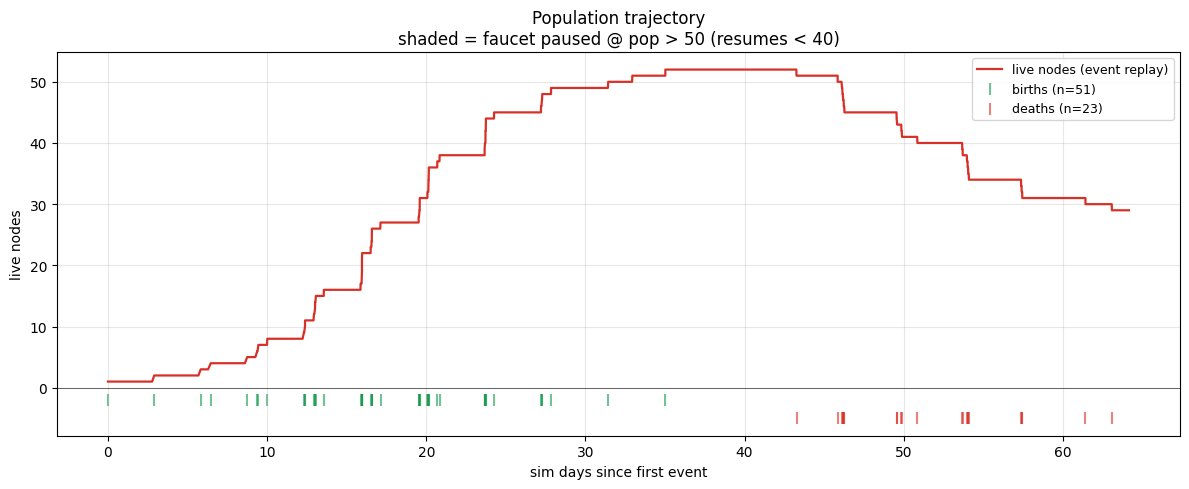

In [35]:
# 2. Population trajectory with phase annotations.
import numpy as np

ts_axis = sorted(df['ts'].unique())
populations = live_count_at(ts_axis)

births_ts = df.loc[df['event'] == 'birth', 'ts'].tolist()
deaths_ts = (
    df[df['event'] == 'server_expired']
      .dropna(subset=['data.friendly_name'])['ts']
      .tolist()
)

# Pair faucet pause/resume into bands robustly (handles dropped events / ordering quirks).
pr = pd.concat([
    df.loc[df['event'] == 'faucet_paused', ['ts']].assign(kind='pause'),
    df.loc[df['event'] == 'faucet_resumed', ['ts']].assign(kind='resume'),
]).sort_values('ts').reset_index(drop=True)

bands, open_p = [], None
for _, ev in pr.iterrows():
    if ev['kind'] == 'pause' and open_p is None:
        open_p = ev['ts']
    elif ev['kind'] == 'resume' and open_p is not None:
        bands.append((open_p, ev['ts']))
        open_p = None
if open_p is not None:
    bands.append((open_p, df['ts'].max()))

to_days = lambda ts: (ts - t0) * TIME_SCALE / 86400

fig, ax = plt.subplots(figsize=(12, 5))
for i, (p, r) in enumerate(bands):
    ax.axvspan(to_days(p), to_days(r), color='#d73027', alpha=0.25,
               label='faucet paused' if i == 0 else None)
ax.plot([to_days(t) for t in ts_axis], populations,
        color='#d73027', lw=1.6, label='live nodes (event replay)')

ax.scatter([to_days(t) for t in births_ts], [-2] * len(births_ts),
           marker='|', color='#1a9850', s=80, alpha=0.6,
           label=f'births (n={len(births_ts)})')
ax.scatter([to_days(t) for t in deaths_ts], [-5] * len(deaths_ts),
           marker='|', color='#d73027', s=80, alpha=0.6,
           label=f'deaths (n={len(deaths_ts)})')

peak_pop = max(populations)
peak_day = to_days(ts_axis[populations.index(peak_pop)])

ax.axhline(0, color='black', lw=0.4)
ax.set_xlabel('sim days since first event')
ax.set_ylabel('live nodes')
ax.set_title('Population trajectory\n'
             'shaded = faucet paused @ pop > 50 (resumes < 40)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

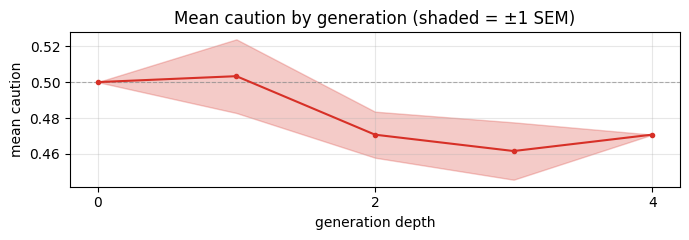

In [36]:
# 3. Mean caution by generation depth (compact line + SEM band).
from collections import defaultdict
import numpy as np

gen_caution = defaultdict(list)
for node, c in caution_by_node.items():
    if pd.isna(c):
        continue
    d = depth_labels.get(node)
    if isinstance(d, int):
        gen_caution[d].append(float(c))

gens = sorted(gen_caution)
means = np.array([np.mean(gen_caution[g]) for g in gens])
sems = np.array([
    np.std(gen_caution[g], ddof=1) / np.sqrt(len(gen_caution[g]))
    if len(gen_caution[g]) > 1 else 0.0
    for g in gens
])

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.6)  # neutral / genesis baseline
ax.fill_between(gens, means - sems, means + sems, color='#d73027', alpha=0.25)
ax.plot(gens, means, color='#d73027', marker='o', ms=3, lw=1.5)
ax.set_xlabel('generation depth')
ax.set_ylabel('mean caution')
ax.set_xticks(gens[::2])
ax.grid(True, alpha=0.3)
ax.set_title('Mean caution by generation (shaded = ±1 SEM)')
plt.tight_layout()
plt.show()


0 marks every 90 sim-days over 64 sim-days


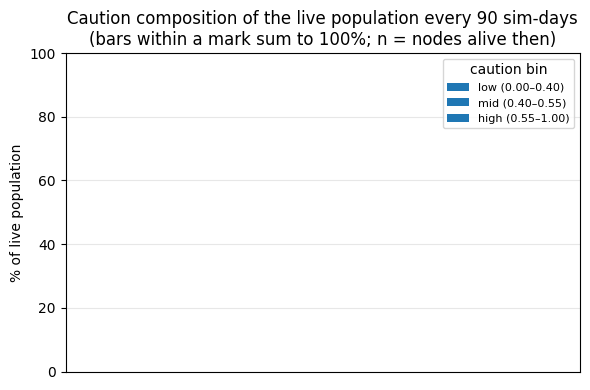

In [37]:
# 4. Caution composition of the live population over time.
# Single clustered bar chart: x = elapsed-time marks, and within each mark the 3
# bars give the share of the *currently-alive* population (born by that mark and
# not yet expired) in each caution bin. Bars within a mark sum to 100%.
#
# Turn BUCKET_DAYS to change time resolution: 365 = yearly, 182 ≈ half-year,
# 90 = quarterly, 30 = monthly. Marks are placed every BUCKET_DAYS sim-days.
import numpy as np

BUCKET_DAYS = 90

# Caution bin edges (knob): low < 0.40, mid 0.40–0.55, high > 0.55.
bins = [0.0, 0.40, 0.55, 1.0]
N_BINS = len(bins) - 1
bin_names = ['low', 'mid', 'high']
colors = ['#d73027', '#fdae61', '#1a9850']

birth_ts = df[df['event'] == 'birth'].groupby('node')['ts'].min()
death_ts = (
    df[df['event'] == 'server_expired']
      .groupby('data.friendly_name')['ts'].min()
)
t0 = df['ts'].min()
SEC_PER_SIM_DAY = 86400 / TIME_SCALE
span_days = (df['ts'].max() - t0) / SEC_PER_SIM_DAY
mark_days = [k * BUCKET_DAYS for k in range(1, int(span_days // BUCKET_DAYS) + 1)]
print(f'{len(mark_days)} marks every {BUCKET_DAYS} sim-days over {span_days:.0f} sim-days')

rows = []
for node, c in caution_by_node.items():
    if pd.isna(c) or node not in G:
        continue
    rows.append({
        'node': node, 'caution': float(c),
        'birth': birth_ts.get(node), 'death': death_ts.get(node),
    })
cdf = pd.DataFrame(rows)
cdf['bin'] = pd.cut(cdf['caution'], bins, include_lowest=True)
categories = cdf['bin'].cat.categories

# shares[bin, mark] = % of nodes alive at that mark falling in the bin.
shares = np.zeros((N_BINS, len(mark_days)))
n_alive = []
for j, d in enumerate(mark_days):
    mark = t0 + d * SEC_PER_SIM_DAY
    alive = cdf[
        cdf['birth'].notna() & (cdf['birth'] <= mark) &
        (cdf['death'].isna() | (cdf['death'] > mark))
    ]
    n_alive.append(len(alive))
    counts = alive.groupby('bin', observed=False).size().reindex(categories, fill_value=0)
    if len(alive):
        shares[:, j] = counts.values / len(alive) * 100

# Whole years read as "Ny" when the bucket divides evenly; otherwise sim-days.
use_years = (BUCKET_DAYS % 365 == 0)
fmt_mark = (lambda d: f'{d // 365}y') if use_years else (lambda d: f'{d}d')

x = np.arange(len(mark_days))
width = 0.26

fig, ax = plt.subplots(figsize=(max(6, 0.9 * len(mark_days) + 2), 4))
for i in range(N_BINS):
    ax.bar(
        x + (i - 1) * width, shares[i], width,
        color=colors[i], edgecolor='black', linewidth=0.4,
        label=f'{bin_names[i]} ({bins[i]:.2f}–{bins[i+1]:.2f})',
    )

ax.set_xticks(x)
ax.set_xticklabels([f'{fmt_mark(d)}\n(n={n})' for d, n in zip(mark_days, n_alive)],
                   fontsize=8)
ax.set_ylabel('% of live population')
ax.set_ylim(0, 100)
ax.set_title(f'Caution composition of the live population every {BUCKET_DAYS} sim-days\n'
             '(bars within a mark sum to 100%; n = nodes alive then)')
ax.legend(title='caution bin', fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


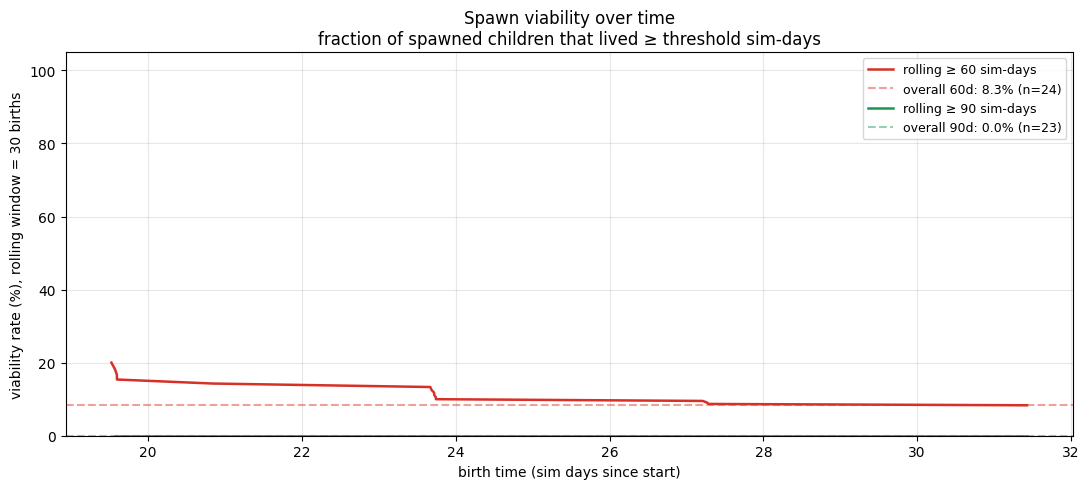

In [38]:
# 5. Spawn viability rate over time.
# For each spawned child, did it live ≥ N sim-days? Rolling fraction by birth order.
import numpy as np

birth_ts_d1 = df.loc[df['event'] == 'birth'].set_index('node')['ts'].to_dict()
last_seen = snaps.groupby('node')['ts'].max().to_dict()
for _, row in df[df['event'] == 'server_expired'].iterrows():
    n = row.get('data.friendly_name')
    if isinstance(n, str) and n:
        last_seen[n] = max(last_seen.get(n, row['ts']), row['ts'])

records = []
for node, bts in birth_ts_d1.items():
    lts = last_seen.get(node, bts)
    age_days = (lts - bts) * TIME_SCALE / 86400
    records.append({
        'node': node,
        'birth_sim_day': (bts - t0) * TIME_SCALE / 86400,
        'age_days': age_days,
        'censored': node not in dead_nodes,
    })
vdf = pd.DataFrame(records).sort_values('birth_sim_day').reset_index(drop=True)

THRESHOLDS = [60, 90]
WINDOW = 30
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#d73027', '#1a9850']

for thr, col in zip(THRESHOLDS, colors):
    # Drop births that are still alive AND too young to classify yet
    classified = vdf[~((vdf['censored']) & (vdf['age_days'] < thr))].copy()
    if len(classified) < 3:
        continue
    classified['viable'] = classified['age_days'] >= thr
    rolling = classified['viable'].rolling(WINDOW, min_periods=max(3, WINDOW // 3)).mean()
    overall = classified['viable'].mean()
    ax.plot(classified['birth_sim_day'], rolling * 100,
            color=col, lw=1.8, label=f'rolling ≥ {thr} sim-days')
    ax.axhline(overall * 100, color=col, ls='--', alpha=0.45,
               label=f'overall {thr}d: {overall*100:.1f}% (n={len(classified)})')

ax.set_xlabel('birth time (sim days since start)')
ax.set_ylabel(f'viability rate (%), rolling window = {WINDOW} births')
ax.set_ylim(0, 105)
ax.set_title('Spawn viability over time\n'
             'fraction of spawned children that lived ≥ threshold sim-days')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


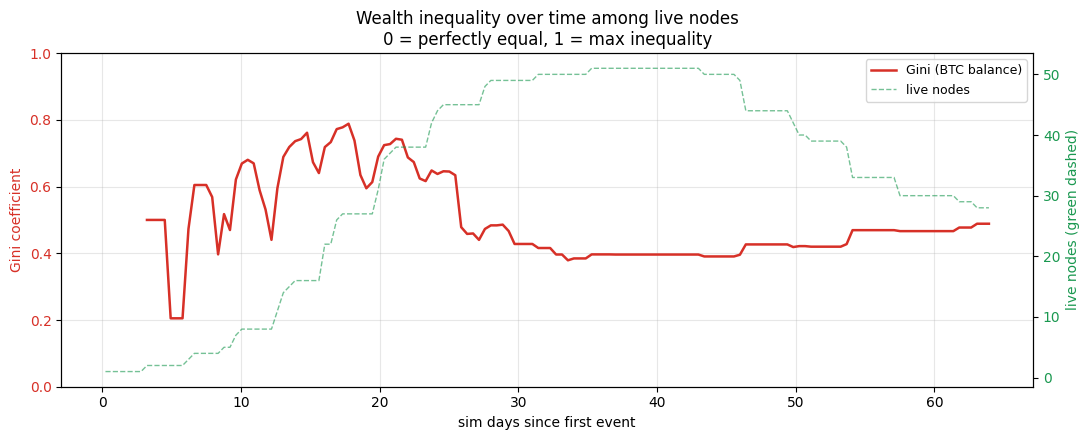

In [39]:
# 6. Wealth inequality (Gini) over time, using live nodes' latest balance.
import numpy as np

def gini(values):
    v = np.asarray(values, dtype=float)
    v = v[(~np.isnan(v)) & (v >= 0)]
    if len(v) < 2 or v.sum() == 0:
        return np.nan
    v = np.sort(v)
    n = len(v)
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * v) - (n + 1) * v.sum()) / (n * v.sum())

N_BINS_G = 150
ts_min, ts_max = df['ts'].min(), df['ts'].max()
edges = np.linspace(ts_min, ts_max, N_BINS_G + 1)
centers = (edges[:-1] + edges[1:]) / 2

bal = snaps[['ts', 'node', 'data.btc_balance_sat']].dropna(subset=['data.btc_balance_sat'])
bal = bal.sort_values('ts')

# Liveness comes from the backend (live_nodes_at, event replay); the balance for
# each live node is its latest snapshot as of the bin center.
gini_series, n_live_series = [], []
for b in centers:
    alive = live_nodes_at(b)
    window = bal[(bal['ts'] <= b) & (bal['node'].isin(alive))]
    latest = window.groupby('node')['data.btc_balance_sat'].last()
    gini_series.append(gini(latest.values))
    n_live_series.append(len(latest))

sim_days = [(b - t0) * TIME_SCALE / 86400 for b in centers]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(sim_days, gini_series, color='#d73027', lw=1.8, label='Gini (BTC balance)')
ax.set_xlabel('sim days since first event')
ax.set_ylabel('Gini coefficient', color='#d73027')
ax.set_ylim(0, 1)
ax.tick_params(axis='y', labelcolor='#d73027')
ax.grid(True, alpha=0.3)

ax2 = ax.twinx()
ax2.plot(sim_days, n_live_series, color='#1a9850', lw=1.0, alpha=0.6, ls='--',
         label='live nodes')
ax2.set_ylabel('live nodes (green dashed)', color='#1a9850')
ax2.tick_params(axis='y', labelcolor='#1a9850')

ax.set_title('Wealth inequality over time among live nodes\n'
             '0 = perfectly equal, 1 = max inequality')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()